In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Environment Ready")

✅ Environment Ready


In [20]:
# Connect to your SQLite DB
conn = sqlite3.connect('../data/propiq.db')
df = pd.read_sql_query("SELECT * FROM listings", conn)
conn.close()

# THE FIX: Force names to lowercase and remove all spaces/underscores
df.columns = [col.lower().replace(' ', '').replace('_', '') for col in df.columns]

print(f"📊 Dataset Loaded: {df.shape[0]} rows.")
print(f"Verified Columns: 'saleprice' and 'overallqual' are ready.")
df.head(2)

📊 Dataset Loaded: 2930 rows.
Verified Columns: 'saleprice' and 'overallqual' are ready.


,order,pid,mssubclass,mszoning,lotfrontage,lotarea,street,alley,lotshape,landcontour,...,poolarea,poolqc,fence,miscfeature,miscval,mosold,yrsold,saletype,salecondition,saleprice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000


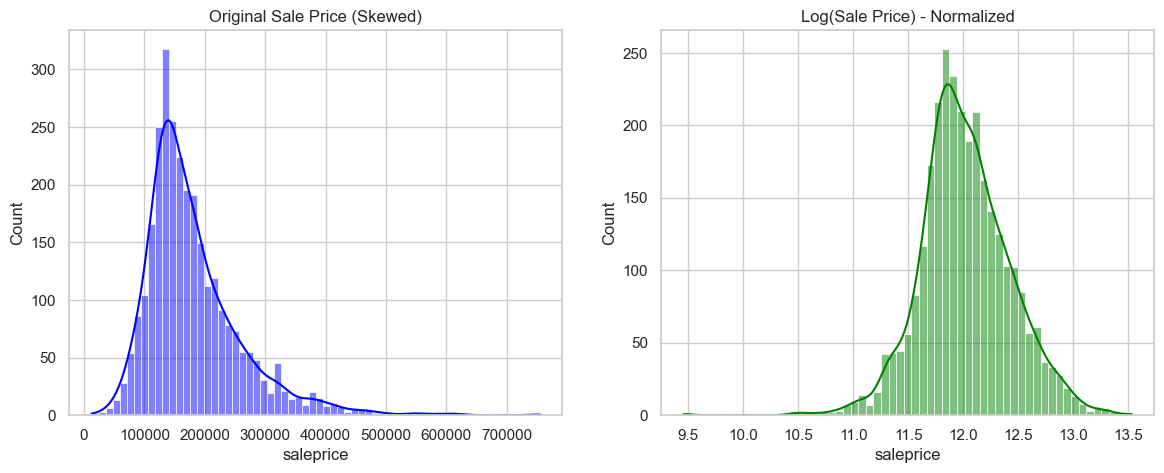

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Raw Skewed Data
sns.histplot(df['saleprice'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Original Sale Price (Skewed)')

# Plot 2: Log Normal Data
sns.histplot(np.log1p(df['saleprice']), kde=True, ax=axes[1], color='green')
axes[1].set_title('Log(Sale Price) - Normalized')

plt.show()

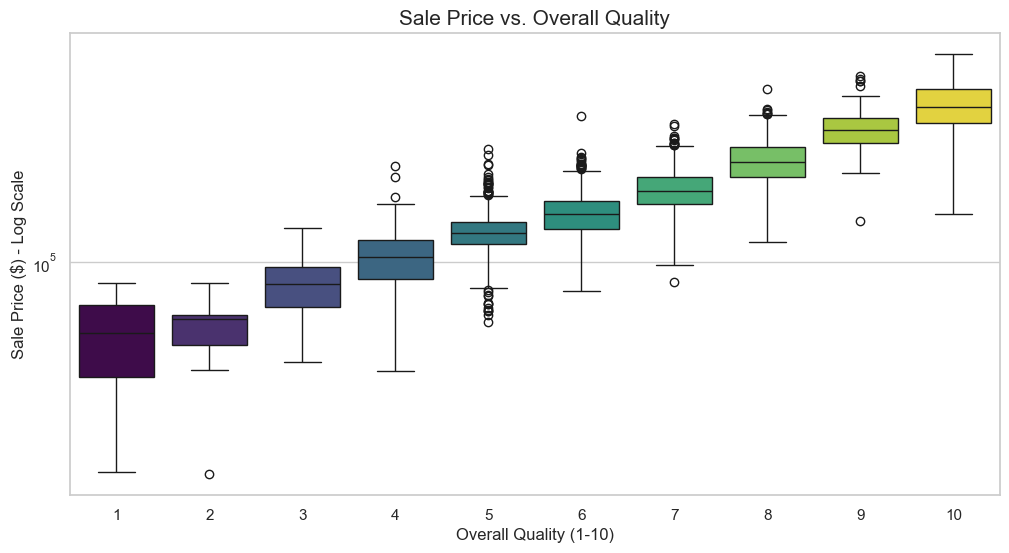

In [22]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='overallqual', y='saleprice', data=df, hue='overallqual', palette='viridis', legend=False)

plt.title('Sale Price vs. Overall Quality', fontsize=15)
plt.yscale('log') 
plt.xlabel('Overall Quality (1-10)')
plt.ylabel('Sale Price ($) - Log Scale')
plt.show()

In [23]:
missing_report = df.isnull().sum()
missing_report = missing_report[missing_report > 0].sort_values(ascending=False)

print("🚩 Data Quality Report: Missing Values")
if not missing_report.empty:
    # Show top 20 missing
    print(missing_report.head(20))
else:
    print("No missing values found!")

🚩 Data Quality Report: Missing Values
poolqc          2917
miscfeature     2824
alley           2732
fence           2358
masvnrtype      1775
fireplacequ     1422
lotfrontage      490
garagequal       159
garagecond       159
garageyrblt      159
garagefinish     159
garagetype       157
bsmtexposure      83
bsmtfintype2      81
bsmtcond          80
bsmtqual          80
bsmtfintype1      80
masvnrarea        23
bsmtfullbath       2
bsmthalfbath       2
dtype: int64
